In [1]:
# Load the datasets

import pandas as pd

m2 = pd.read_csv("milestone2.csv")
m3 = pd.read_csv("milestone3.csv")
m4 = pd.read_csv("milestone4.csv")

print(m2.shape, m3.shape, m4.shape)

(3000, 15) (239, 4) (230, 15)


In [2]:
# Load them into SQLite as tables

import sqlite3

conn = sqlite3.connect("covid_project.db")

m2.to_sql("dataset_m2", conn, if_exists="replace", index=False)
m3.to_sql("dataset_m3", conn, if_exists="replace", index=False)
m4.to_sql("dataset_m4", conn, if_exists="replace", index=False)

print("Tables loaded into SQLite")

Tables loaded into SQLite


In [3]:
# Verify tables

query = """
SELECT name 
FROM sqlite_master 
WHERE type='table';
"""

tables = pd.read_sql_query(query, conn)
print("Tables in database:")
print(tables)

Tables in database:
         name
0  dataset_m2
1  dataset_m3
2  dataset_m4


# Preview sample rows from each table

In [4]:
# Dataset from Milestone 2

sample_m2 = pd.read_sql_query("SELECT * FROM dataset_m2 LIMIT 5;", conn)
print("Sample data from dataset_m2:")
print(sample_m2)

Sample data from dataset_m2:
         date      continent  country  total_cases  new_cases  total_deaths  \
0  11/19/2021           Asia    India    6423388.0       2490        107051   
1  09/12/2021  North America   Russia    6550634.0       6980        481184   
2  04/20/2020         Europe   Canada    4304572.0       9134         15116   
3  10/16/2022           Asia  Germany    2234489.0       7661         20045   
4  05/15/2021         Europe      Usa    9958614.0       1724        419543   

   new_deaths  total_tests  total_vaccinations  people_vaccinated  \
0         323     60016385            55863236           35276326   
1         697     28666409            63799592           67830632   
2         325     80352550            68770121           68985000   
3         624     89212990            97546509           17081923   
4         824      5364240            31976637           52813396   

   hosp_patients  population  median_age  gdp_per_capita  case_fatality_rate  
0 

In [5]:
# Dataset from milestone 3

sample_m3 = pd.read_sql_query("SELECT * FROM dataset_m3 LIMIT 5;", conn)
print("Sample data from dataset_m3:")
print(sample_m3)

Sample data from dataset_m3:
                  country  deaths_per_million   deaths      cases
0             World [ A ]                 893  7110645  779035962
1                    Peru                6603   221067    4533436
2                Bulgaria                5680    38777    1341038
3         North Macedonia                5429     9991     352093
4  Bosnia And Herzegovina                5119    16407     404289


In [6]:
# Dataset from Milestone 4

sample_m4 = pd.read_sql_query("SELECT * FROM dataset_m4 LIMIT 5;", conn)
print("Sample data from dataset_m4:")
print(sample_m4)

Sample data from dataset_m4:
         country iso2 iso3               updated_dt  population       cases  \
0         Brunei   BN  BRN  2026-03-04 04:10:44.783    445431.0    343719.0   
1     San Marino   SM  SMR  2026-03-04 04:10:44.857     34085.0     26185.0   
2  Faroe Islands   FO  FRO  2026-03-04 04:10:44.847     49233.0     34658.0   
3       S. Korea   KR  KOR  2026-03-04 04:10:44.645  51329899.0  34571873.0   
4        Austria   AT  AUT  2026-03-04 04:10:44.677   9066710.0   6081287.0   

    deaths   recovered   active        tests  cases_per_million  \
0    225.0    243601.0  99893.0     717784.0      771654.869104   
1    128.0     26011.0     46.0     196855.0      768226.492592   
2     28.0         0.0  34630.0     778000.0      703958.726870   
3  35934.0  34535939.0      0.0   15804065.0      673523.105900   
4  22542.0   6054934.0   3811.0  211273524.0      670726.978143   

   deaths_per_million  tests_per_million  cfr_percent  cases_pm_outlier  
0          505.1287

# Join the tables using SQL

In [7]:
query = """
SELECT *
FROM dataset_m4 a
LEFT JOIN dataset_m3 b
ON a.country = b.country
LEFT JOIN dataset_m2 c
ON a.country = c.country
"""

joined_df = pd.read_sql_query(query, conn)

joined_df.head()

,country,iso2,iso3,updated_dt,population,cases,deaths,recovered,active,tests,...,total_deaths,new_deaths,total_tests,total_vaccinations,people_vaccinated,hosp_patients,population,median_age,gdp_per_capita,case_fatality_rate
0,Brunei,BN,BRN,2026-03-04 04:10:44.783,445431.0,343719.0,225.0,243601.0,99893.0,717784.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,San Marino,SM,SMR,2026-03-04 04:10:44.857,34085.0,26185.0,128.0,26011.0,46.0,196855.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Faroe Islands,FO,FRO,2026-03-04 04:10:44.847,49233.0,34658.0,28.0,0.0,34630.0,778000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,S. Korea,KR,KOR,2026-03-04 04:10:44.645,51329899.0,34571873.0,35934.0,34535939.0,0.0,15804065.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Austria,AT,AUT,2026-03-04 04:10:44.677,9066710.0,6081287.0,22542.0,6054934.0,3811.0,211273524.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
joined_df.columns[joined_df.columns.duplicated()].tolist()

['country', 'deaths_per_million', 'deaths', 'cases', 'country', 'population']

In [10]:
# Keep only the first instance of any duplicated column name. In this case its 'country' as we can see from the output above
joined_df_fixed = joined_df.loc[:, ~joined_df.columns.duplicated()].copy()

# Then write to SQLite
joined_df_fixed.to_sql("final_joined_dataset", conn, if_exists="replace", index=False)
print("Saved final_joined_dataset without duplicate column names.")

Saved final_joined_dataset without duplicate column names.


In [11]:
# Close connection
conn.close()

# Visualizations

In [12]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect("covid_project.db")

df = pd.read_sql_query("SELECT * FROM final_joined_dataset", conn)

df.head()

,country,iso2,iso3,updated_dt,population,cases,deaths,recovered,active,tests,...,new_cases,total_deaths,new_deaths,total_tests,total_vaccinations,people_vaccinated,hosp_patients,median_age,gdp_per_capita,case_fatality_rate
0,Brunei,BN,BRN,2026-03-04 04:10:44.783,445431.0,343719.0,225.0,243601.0,99893.0,717784.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,San Marino,SM,SMR,2026-03-04 04:10:44.857,34085.0,26185.0,128.0,26011.0,46.0,196855.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Faroe Islands,FO,FRO,2026-03-04 04:10:44.847,49233.0,34658.0,28.0,0.0,34630.0,778000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,S. Korea,KR,KOR,2026-03-04 04:10:44.645,51329899.0,34571873.0,35934.0,34535939.0,0.0,15804065.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Austria,AT,AUT,2026-03-04 04:10:44.677,9066710.0,6081287.0,22542.0,6054934.0,3811.0,211273524.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
print(df.shape)
print(df["country"].nunique())

(2628, 28)
230


# Top 10 Countries by Total Cases

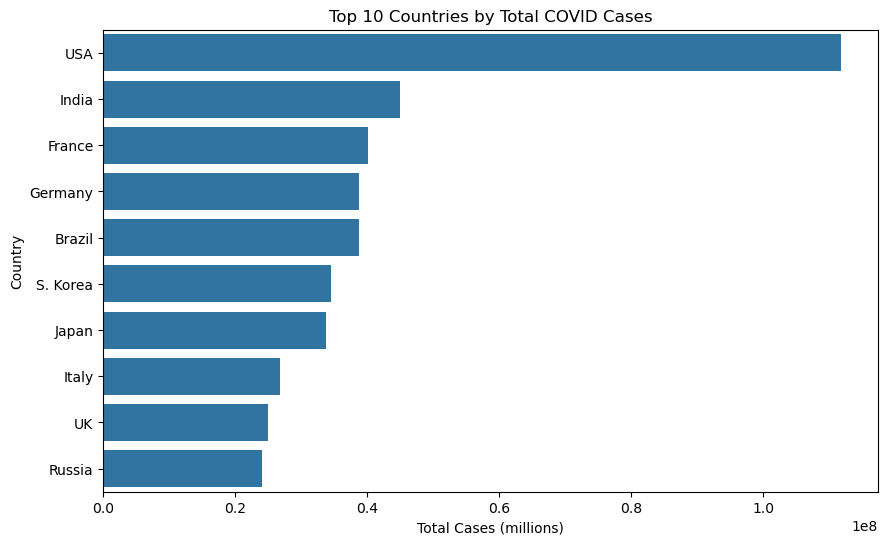

In [30]:
# Time-series data required aggregation by country before performing comparative visualizations, 
# as each country contained multiple records across different dates.

top_cases = (
    df.groupby("country")["cases"]
    .max()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(x="cases", y="country", data=top_cases)

plt.title("Top 10 Countries by Total COVID Cases")
plt.xlabel("Total Cases (millions)")
plt.ylabel("Country")

plt.savefig("top_cases_chart.png", bbox_inches="tight")

plt.show()

# Cases vs Deaths (Aggregated by Country)

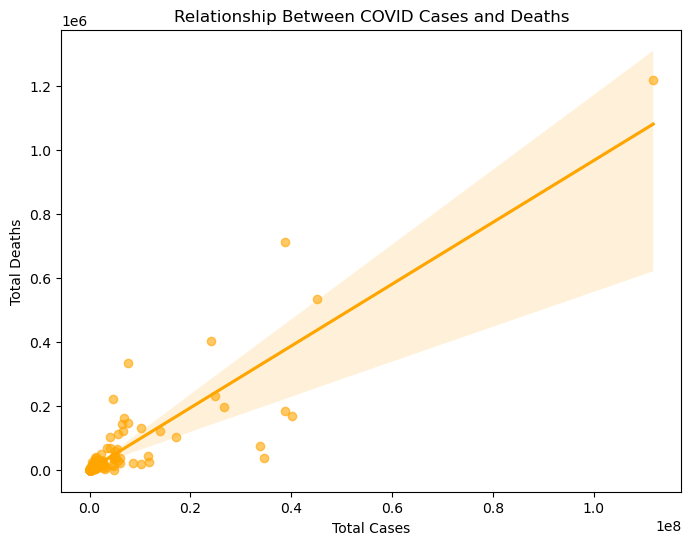

In [31]:
viz2 = (
    df.groupby("country")[["cases","deaths"]]
    .max()
    .reset_index()
)

plt.figure(figsize=(8,6))

sns.regplot(
    data=viz2,
    x="cases",
    y="deaths",
    color="orange",
    scatter_kws={"alpha":0.6}
)

plt.title("Relationship Between COVID Cases and Deaths")
plt.xlabel("Total Cases")
plt.ylabel("Total Deaths")

plt.savefig("cases_vs_deaths.png", bbox_inches="tight")

plt.show()

# Population vs Cases per Million

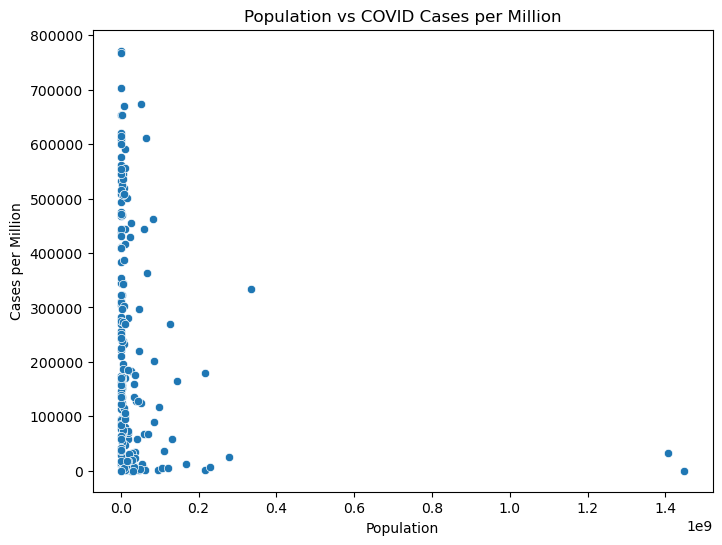

In [32]:
viz3 = (
    df.groupby("country")[["population","cases_per_million"]]
    .max()
    .reset_index()
)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=viz3,
    x="population",
    y="cases_per_million"
)

plt.title("Population vs COVID Cases per Million")
plt.xlabel("Population")
plt.ylabel("Cases per Million")

plt.savefig("population_cases.png", bbox_inches="tight")

plt.show()

# Compare Case Fatality Rate from Two Sources

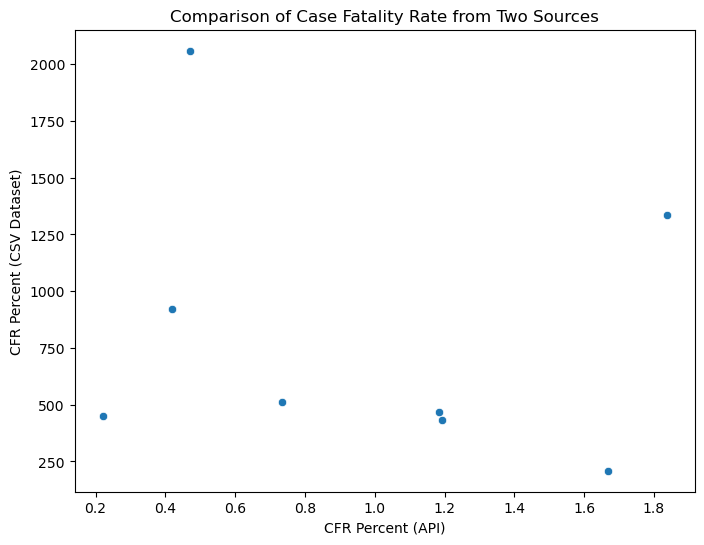

In [33]:
viz4 = (
    df.groupby("country")[["cfr_percent","case_fatality_rate"]]
    .max()
    .reset_index()
)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=viz4,
    x="cfr_percent",
    y="case_fatality_rate"
)

plt.title("Comparison of Case Fatality Rate from Two Sources")
plt.xlabel("CFR Percent (API)")
plt.ylabel("CFR Percent (CSV Dataset)")

plt.savefig("cfr_comparison.png", bbox_inches="tight")

plt.show()

# GDP per Capita vs Fatality Rate

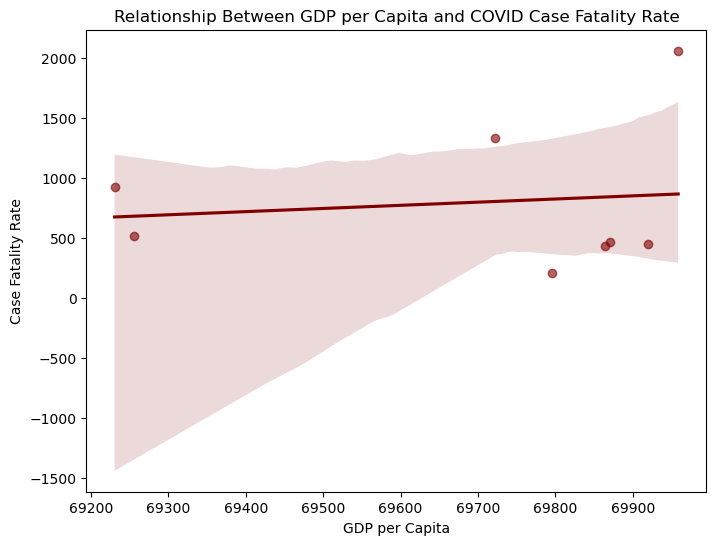

In [34]:
viz5 = (
    df.groupby("country")[["gdp_per_capita","case_fatality_rate"]]
    .max()
    .reset_index()
)

plt.figure(figsize=(8,6))

sns.regplot(
    data=viz5,
    x="gdp_per_capita",
    y="case_fatality_rate",
    color="maroon",
    scatter_kws={"alpha":0.6}
)

plt.title("Relationship Between GDP per Capita and COVID Case Fatality Rate")
plt.xlabel("GDP per Capita")
plt.ylabel("Case Fatality Rate")

plt.savefig("gdp_fatality.png", bbox_inches="tight")

plt.show()

In [29]:
# Close database connection

conn.close()

# Project Summary

This project involved collecting, cleaning, transforming, and integrating COVID-19 data from multiple sources including a CSV dataset, a web-scraped Wikipedia table, and an API dataset. Each dataset contained similar information about COVID-19 cases, deaths, and population statistics but differed in format, column naming conventions, and levels of completeness. The first step in the process was to clean each dataset individually in Milestones 2 through 4. This involved tasks such as removing missing values, standardizing column names, converting data types, and ensuring that country names were consistent across all datasets. These steps were necessary to allow the datasets to be merged accurately.

After the data was cleaned, the datasets were exported and loaded into a SQLite database where each dataset was stored as a separate table. SQL joins were then used to combine the datasets into a single consolidated dataset based on a common country field. Using SQL joins allowed information from multiple sources to be integrated, which improved the completeness and reliability of the final dataset. Once the data was stored in the database, Python libraries such as Pandas, Matplotlib, and Seaborn were used to generate visualizations that explored patterns in COVID-19 cases, deaths, population statistics, and case fatality rates across countries.

One important ethical consideration when cleaning and transforming data is ensuring that the process does not introduce bias or misrepresent the original data. Decisions such as removing missing values, standardizing fields, or merging datasets can influence analytical results if they are not documented carefully. Transparency and reproducibility are critical in data preparation so that others can understand how the final dataset was created. Additionally, when working with global health data such as COVID-19 statistics, it is important to recognize that data collection methods vary by country, which can lead to inconsistencies or reporting differences. Being mindful of these limitations helps ensure that conclusions drawn from the data remain responsible and accurate.
